# Workshop on sensor processing using machine learning
Course: Intelligent Sensing and Sense Making

Website: https://www.iss.nus.edu.sg/executive-education/course/detail/intelligent-sensing-and-sense--making/artificial-intelligence

Contact: Tian Jing

Email: tianjing@nus.edu.sg

**Objective**: In this workshop, we will perform anomaly detection using autoencoder as reconstruction model. The machine health monitoring dataset is provided at https://github.com/ClockworkBunny/MHMS_DEEPLEARNING


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
print("PyTorch version is", torch.__version__)
# Use GPU if available else revert to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device being used:", device)


PyTorch version is 2.14.0+cpu
Device being used: cpu


In [2]:
# Grant access to google drive.
# Run this cell, then you’ll see a link, click on that link, allow access
# Copy the code that pops up, paste it in the box, hit Enter

# Local execution replaces the Google Colab/Drive mount.
from pathlib import Path
local_candidates = [Path.cwd(), Path.cwd() / 'Part3' / 'Day3' / 'Day3']
local_day3 = next((path for path in local_candidates if (path / 'data' / 'machine_sensor_train.csv').exists()), None)
if local_day3 is None:
    raise FileNotFoundError('Cannot find the local Day3 data folder.')
os.chdir(local_day3)
print('Working directory:', os.getcwd())
print('Files:', os.listdir('.'))


Working directory: C:\Users\Setekh\Desktop\ISY5002\Part3\Day3\Day3
Files: ['data', 'ISSM_Day3_wk_anomaly_WangMingyang.ipynb', 'ISSM_Day3_wk_anomaly_yourname.ipynb']


In [3]:
# Load data
x_train_pd = pd.read_csv("data/machine_sensor_train.csv",header=None)
x_train = x_train_pd.values
x_test_pd = pd.read_csv("data/machine_sensor_test.csv",header=None)
x_test = x_test_pd.values

print('Train shape: ', x_train.shape, 'Test shape:', x_test.shape)

Train shape:  (600, 70) Test shape: (300, 70)


In [4]:
# Define the model
class myDataset(torch.utils.data.Dataset):
    def __init__(self, x_data):
        self.X = x_data
        self.num_samples = x_data.shape[0]

    def __getitem__(self, index):
        return self.X[index].astype('float32')

    def __len__(self):
        return self.num_samples

class myAEModel(nn.Module):
    def __init__(self, input_node, hidden_node):
        super(myAEModel, self).__init__()
        self.fc1 = nn.Sequential(nn.Linear(input_node, hidden_node), nn.ReLU())
        self.fc2 = nn.Sequential(nn.Linear(hidden_node, input_node)) # Note that the input signal has a range [-1,1], so we cannot use ReLU in the last layer

    def encode(self, x):
        z = self.fc1(x)
        return z

    def decode(self, x):
        z = self.fc2(x)
        return z

    def forward(self, x):
        z = self.encode(x)
        z = self.decode(z)
        return z

In [5]:
batch_size = 24
train_dataloader = torch.utils.data.DataLoader(myDataset(x_train), shuffle=True, batch_size=batch_size)

# # # Check dimension of a batch of training data
result = next(iter(train_dataloader))
print(result.shape)

input_node = x_train.shape[1]
hidden_node = 10
model = myAEModel(input_node, hidden_node)

model.to(device)
criterion = nn.MSELoss()
learning_rate = 1e-4
num_epoch = 20
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

for epoch in range(num_epoch):
    running_loss = 0.0
    for i, data in enumerate(train_dataloader):
        data = data.to(device)

        output = model(data)
        loss_mse = criterion(data, output)

        optimizer.zero_grad()
        loss_mse.backward()
        optimizer.step()

        running_loss += loss_mse.cpu().item()

    print("Epoch: %d, loss: %.4f" % (epoch+1, loss_mse.cpu().item()))

torch.Size([24, 70])


Epoch: 1, loss: 0.4688
Epoch: 2, loss: 0.4359
Epoch: 3, loss: 0.4141
Epoch: 4, loss: 0.4880
Epoch: 5, loss: 0.4518
Epoch: 6, loss: 0.4266
Epoch: 7, loss: 0.3752
Epoch: 8, loss: 0.3578
Epoch: 9, loss: 0.3716
Epoch: 10, loss: 0.3490
Epoch: 11, loss: 0.3414
Epoch: 12, loss: 0.3122
Epoch: 13, loss: 0.3142


Epoch: 14, loss: 0.2718
Epoch: 15, loss: 0.2700
Epoch: 16, loss: 0.2571
Epoch: 17, loss: 0.2656
Epoch: 18, loss: 0.2497
Epoch: 19, loss: 0.2288
Epoch: 20, loss: 0.2069


In [6]:
# Select a test sample
sample_index = 0

# Step 1: Select the test sample (such as the 0-th sample)
test_data_orig = x_test[sample_index:sample_index+1,:]
test_data_orig = torch.from_numpy(test_data_orig.astype('float32'))

model.eval()
with torch.no_grad():

        test_data_orig = test_data_orig.to(device)
        output = model(test_data_orig)
        dist = F.pairwise_distance(test_data_orig, output)
        print('Dissimlarity: %.4f' % (dist.item()))

print('The reconstruction error is %.2f' % dist)


Dissimlarity: 4.5665
The reconstruction error is 4.57


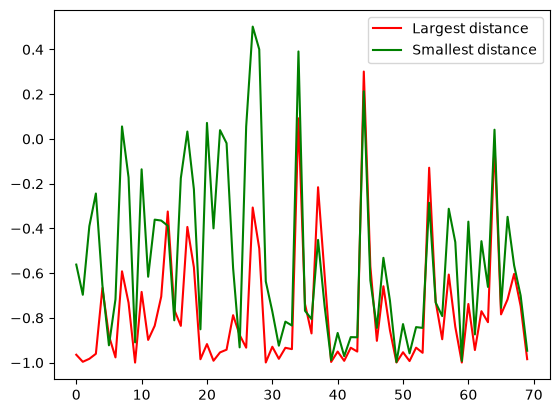

Minimum distance: 198-th sample, Error: 3.70
Maximum distance: 1-th sample, Error: 4.64


In [7]:
# Peform the test on x_test and determine the test data (row index) with the LARGEST reconstruction error based on the trained model
# Plot the data that is found by the model

dist_largest = 0
dist_smallest = 1e10
result_max = 0
result_min = 0

for sample_index in range (x_test.shape[0]):
    test_data_orig = x_test[sample_index:sample_index+1,:]

    # Step 1: Select the test sample (such as the 0-th sample)
    test_data_orig = x_test[sample_index:sample_index+1,:]
    test_data_orig = torch.from_numpy(test_data_orig.astype('float32'))

    model.eval()
    with torch.no_grad():

            test_data_orig = test_data_orig.to(device)
            output = model(test_data_orig)
            dist = F.pairwise_distance(test_data_orig, output)
            # print('Dissimlarity: %.4f' % (dist.item()))

    if (dist>dist_largest):
        dist_largest = dist
        result_max = sample_index
    if (dist<dist_smallest):
        dist_smallest = dist
        result_min = sample_index

plt.plot(x_test[result_max,:], 'r', label='Largest distance')
plt.plot(x_test[result_min,:], 'g', label='Smallest distance')
plt.legend()
plt.show()

print("Minimum distance: %d-th sample, Error: %.2f" % (result_min, dist_smallest))
print("Maximum distance: %d-th sample, Error: %.2f" % (result_max, dist_largest))

$\color{red}{\text{Discussions}}$

Q1: Recommend and describe a method to find a suitable threshold for the reconstruction error used in anomaly detection.

Q2: This workshop uses a generative autoencoder. If considering a contrastive autoencoder, suggest one method to construct the positive pair of samples and negative pair of samples for this task.

## Q1: Selecting a reconstruction-error threshold

Set aside a validation set containing normal samples that is not used to train the autoencoder. Pass these samples through the trained model and calculate their reconstruction errors. A suitable threshold can be set at a high percentile of the normal validation-error distribution, such as the 95th or 99th percentile. A test sample is classified as anomalous when its reconstruction error exceeds this threshold. This percentile-based method is appropriate because reconstruction errors may not follow a normal distribution. If labelled normal and anomalous validation samples are available, sweep across possible thresholds and select the one that gives the best validation metric, such as F1-score or the required balance between false alarms and missed anomalies. The test set should only be used for final evaluation, not for choosing the threshold.

## Q2: Constructing positive and negative pairs

For each machine-sensor sample, construct a positive pair by creating two slightly different views of the same sample using transformations that preserve its operating condition, such as small Gaussian noise, amplitude scaling or masking a small number of sensor values. These two views should have similar representations. Construct a negative pair by pairing the original sample with an anomalous sample, or with a strongly corrupted sample that simulates a different machine condition. The contrastive loss then pulls the positive pair together in the latent space and pushes the negative pair apart, helping the autoencoder distinguish normal operating patterns from anomalies.


## AI Tool Declaration

The authors used GPT-5.6 for text translation and assistance in understanding the code. The authors are responsible for the content and quality of the submitted work.


**After you finish the workshop, rename and submit your .ipynb file.**